> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 01 线性回归：最小二乘、梯度下降与回归评估

**本章目标**：理解线性回归如何用一条直线或超平面拟合连续值，能从最小二乘推导正规方程，
并完成 NumPy 手写、sklearn 回归调用和糖尿病进展预测案例评估。

> 数据来自固定随机种子或 sklearn 内置数据；选择包含 NumPy、Matplotlib、scikit-learn 的内核后可直接 Run All。

## 模型简介与学习参考

线性回归（Linear Regression）是最经典的监督学习回归模型：假设目标值是特征的线性组合，
通过最小化预测残差平方和来学习参数。

| 项目 | 内容 |
|---|---|
| **模型定位** | 预测连续值的监督学习回归模型 |
| **核心思想** | 用线性组合拟合目标，最小化残差平方和 |
| **适用任务** | 价格预测、销量预测、医学指标预测等回归问题 |
| **主要优点** | 可解释性强、训练快速、可作为强基线 |
| **主要限制** | 假设线性关系，对非线性与强交互表达有限 |

**学习参考**：

- 周志华：《机器学习》（西瓜书），第 3 章“线性模型”；
- [Datawhale《南瓜书》](https://github.com/datawhalechina/pumpkin-book)；
- [hands-on-ML：线性模型 Notebook](https://github.com/ForceInjection/hands-on-ML/tree/main/nju_software/ch-03)；
- [scikit-learn：LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)。

本章按照 **原理推导 → NumPy 手写 → sklearn 调用 → 真实案例 → 章节小结** 展开。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 问题定义：连续值预测与线性假设](#problem)
  - [1.2 模型形式：从直线到超平面](#model)
  - [1.3 最小二乘：残差平方和与解析解](#least-squares)
  - [1.4 梯度下降：从 Loss 到参数更新](#gradient)
  - [1.5 评估指标：MSE、RMSE、MAE 与 R²](#metrics)
  - [1.6 完整链路：从特征到预测](#full-chain)
  - [1.7 代码对应：公式与实现](#formula-code)
- [2. NumPy 手写线性回归](#scratch)
  - [2.1 图形复现：三张核心原理图](#figure-code)
  - [2.2 数据准备：一维带噪模拟数据](#scratch-data)
  - [2.3 模型实现：LinearRegressionGD 与正规方程](#scratch-model)
  - [2.4 训练评估：Loss、拟合线与回归指标](#scratch-evaluation)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 回归调用：拟合面与残差评估](#sklearn-basic)
  - [3.2 回归案例：糖尿病进展预测](#real-case)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

<a id="problem"></a>
### 1.1 问题定义：连续值预测与线性假设

以房价预测为例，输入是面积、房龄等特征
\(\boldsymbol x\)，输出是连续价格 \(y\in\mathbb R\)。
回归任务的目标是学习函数 \(f(\boldsymbol x)\approx y\)，
使新样本的预测值尽量接近真实值。

线性回归假设目标值是特征的线性组合：

$$
\hat y=\boldsymbol w^\mathrm T\boldsymbol x+b
$$

其中 \(\boldsymbol w\) 是权重向量，\(b\) 是截距。模型是“线性”的，
指它对**参数** \(\boldsymbol w,b\) 线性，而不是对特征 \(\boldsymbol x\) 线性：
特征可以包含 \(x^2\)、\(\log x\) 等变换，只要参数组合仍是线性的，
就仍属于线性模型。

单个特征时退化为直线
\(\hat y=wx+b\)；多个特征时是特征空间中的超平面。

<a id="model"></a>
### 1.2 模型形式：从直线到超平面

把截距并入权重向量：

$$
\boldsymbol\theta=[b,\boldsymbol w^\mathrm T]^\mathrm T,
\qquad
\widetilde{\boldsymbol X}=[\boldsymbol 1,\boldsymbol X]
$$

模型写成

$$
\hat{\boldsymbol y}=\widetilde{\boldsymbol X}\boldsymbol\theta
$$

训练数据给出 \(n\) 组 \((x_i,y_i)\)。若模型完全正确，应有
\(y_i=\widetilde{\boldsymbol x}_i\boldsymbol\theta\)；但由于噪声和模型偏差，
实际存在残差：

$$
e_i=y_i-\hat y_i=y_i-\widetilde{\boldsymbol x}_i\boldsymbol\theta
$$

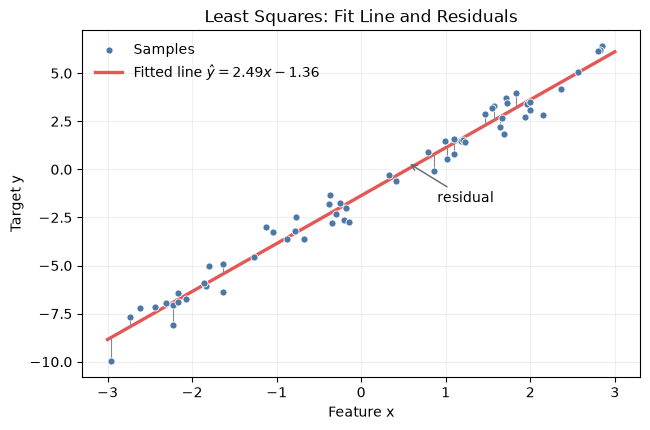

图 1 中残差是每个样本到拟合线的竖直距离（沿 \(y\) 方向）。
最小二乘的核心想法就是让所有残差的平方和尽可能小。

<a id="least-squares"></a>
### 1.3 最小二乘：残差平方和与解析解

定义损失为平均残差平方和：

$$
J(\boldsymbol\theta)
=
\frac1{2n}\sum_{i=1}^{n}
(y_i-\widetilde{\boldsymbol x}_i\boldsymbol\theta)^2
$$

系数 \(1/2\) 只是为了让求导结果更简洁，不影响最优解。
该损失关于 \(\boldsymbol\theta\) 是凸的二次函数，因此可以用解析方法求全局最优解。

对 \(\boldsymbol\theta\) 求导并令梯度为零：

$$
\frac{\partial J}{\partial\boldsymbol\theta}
=
-\frac1n
\widetilde{\boldsymbol X}^\mathrm T
(\boldsymbol y-\widetilde{\boldsymbol X}\boldsymbol\theta)
=0
$$

整理得到**正规方程**：

$$
\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X}
\boldsymbol\theta
=
\widetilde{\boldsymbol X}^\mathrm T\boldsymbol y
\quad\Longrightarrow\quad
\boldsymbol\theta^*
=
(\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X})^{-1}
\widetilde{\boldsymbol X}^\mathrm T\boldsymbol y
$$

正规方程直接给出闭式解。它需要求
\((d+1)\times(d+1)\) 矩阵的逆，计算成本约为 \(O(d^3)\)；
当特征维度很大或 \(\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X}\)
接近奇异时，通常改用梯度下降或伪逆（pinv）求解。

<a id="gradient"></a>
### 1.4 梯度下降：从 Loss 到参数更新

正规方程是闭式解；梯度下降则是迭代法。批量梯度下降的更新规则：

$$
\boldsymbol\theta
\leftarrow
\boldsymbol\theta-\eta\nabla J(\boldsymbol\theta)
=
\boldsymbol\theta+\frac{\eta}{n}
\widetilde{\boldsymbol X}^\mathrm T
(\boldsymbol y-\widetilde{\boldsymbol X}\boldsymbol\theta)
$$

直觉：\(\nabla J\) 指向损失上升最快的方向，沿反方向走一小步就能降低损失。
\(\eta\) 是学习率：过大会震荡甚至发散，过小则收敛缓慢。

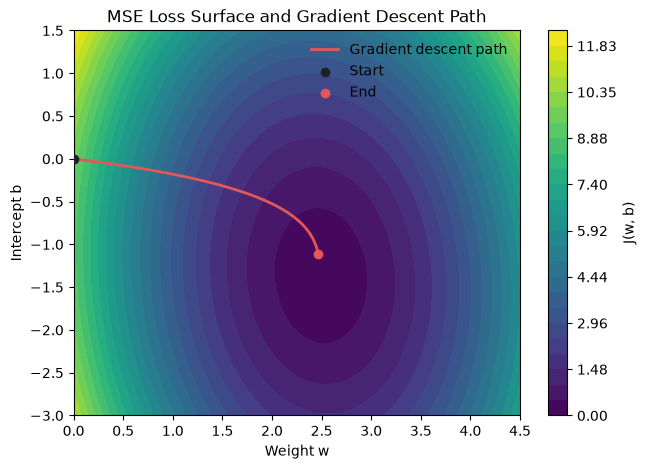

图 2 把 \(J(w,b)\) 画成等高线：它是碗形（凸函数），只有一个全局最小值。
图中叠加了一次梯度下降的迭代轨迹，可以看到参数从初始点逐步滑向谷底。

<a id="metrics"></a>
### 1.5 评估指标：MSE、RMSE、MAE 与 R²

训练用 MSE 做损失；评估时还常看 RMSE、MAE 和 R²：

$$
\mathrm{MSE}
=\frac1n\sum_{i=1}^{n}(y_i-\hat y_i)^2
$$

$$
\mathrm{RMSE}
=\sqrt{\mathrm{MSE}},
\qquad
\mathrm{MAE}
=\frac1n\sum_{i=1}^{n}|y_i-\hat y_i|
$$

$$
R^2
=
1-\frac{\mathrm{SS_{res}}}{\mathrm{SS_{tot}}}
=
1-\frac{\sum_{i=1}^{n}(y_i-\hat y_i)^2}
{\sum_{i=1}^{n}(y_i-\bar y)^2}
$$

\(R^2\) 可解释为“模型解释了多少目标方差”：等于 1 是完美拟合；
等于 0 等价于常数预测 \(\bar y\)；小于 0 表示比均值基线更差。
回归不能只看 \(R^2\)，应结合残差图检查是否存在系统性偏差。

<a id="full-chain"></a>
### 1.6 完整链路：从特征到预测

1. 输入特征，写出线性假设
   \(\hat y=\widetilde{\boldsymbol x}\boldsymbol\theta\)；
2. 定义残差 \(e_i=y_i-\hat y_i\) 与平方损失
   \(J(\boldsymbol\theta)=\frac1{2n}\sum e_i^2\)；
3. 对 \(\boldsymbol\theta\) 求梯度
   \(\nabla J=-\frac1n\widetilde{\boldsymbol X}^\mathrm T
   (\boldsymbol y-\widetilde{\boldsymbol X}\boldsymbol\theta)\)；
4. 令梯度为零得到正规方程
   \(\boldsymbol\theta^*=(\widetilde{\boldsymbol X}^\mathrm T\widetilde{\boldsymbol X})^{-1}
   \widetilde{\boldsymbol X}^\mathrm T\boldsymbol y\)，
   或用梯度下降迭代更新；
5. 用学到的参数对新样本计算 \(\hat y=\widetilde{\boldsymbol x}\boldsymbol\theta\)；
6. 用 MSE、RMSE、MAE、R² 与残差图评估。

```text
连续值预测
→ 线性假设
→ 残差平方和
→ 正规方程 / 梯度下降
→ 最优参数
→ 预测
→ 回归评估
```

<a id="formula-code"></a>
### 1.7 代码对应：公式与实现

| 原理 | 手写实现 |
|---|---|
| 线性模型 \(\hat y=\widetilde X\theta\) | `prediction = X_b @ self.theta_` |
| 残差 \(e=y-\hat y\) | `residual = y - prediction` |
| 损失 \(J=\frac1{2n}\sum e^2\) | `loss = np.mean(residual ** 2) / 2` |
| 梯度 \(\nabla J=-\frac1n\widetilde X^\mathrm Te\) | `gradient = -(X_b.T @ residual) / len(X)` |
| 参数更新 | `self.theta_ -= self.learning_rate * gradient` |
| R² 评估 | `r2 = 1 - ss_res / ss_tot` |

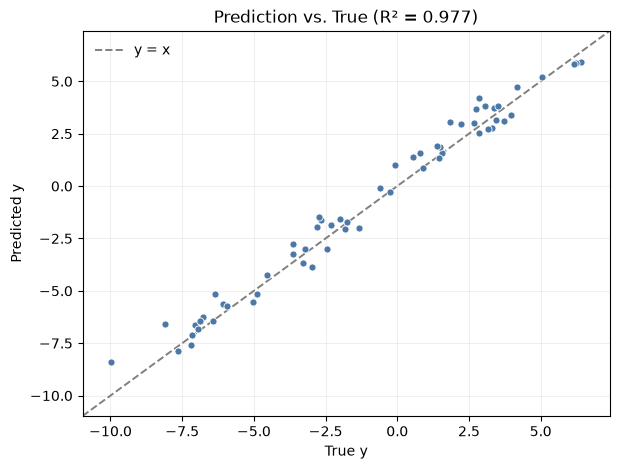

图 3 展示测试集上真实值与预测值的散点：点越贴近对角线 \(y=x\)，
模型越好；\(R^2\) 给出一个数值总结。

<a id="scratch"></a>
## 2. NumPy 手写线性回归

<a id="figure-code"></a>
### 2.1 图形复现：三张核心原理图

以下代码与原理部分的三张嵌入图一一对应。

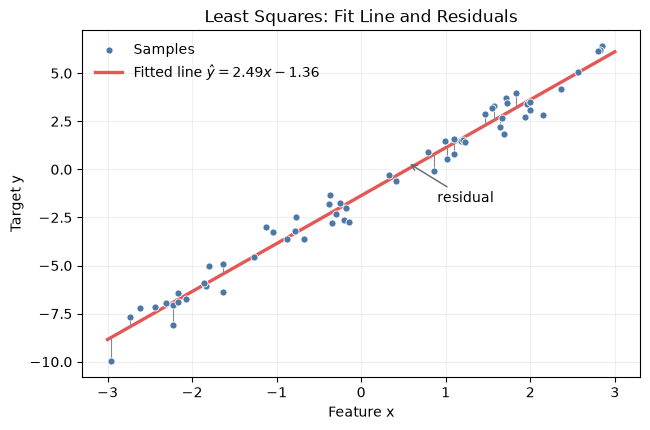

In [1]:
# 复现图 1：拟合直线与残差
import numpy as np
import matplotlib.pyplot as plt

rng_fig = np.random.default_rng(42)
x_fig = rng_fig.uniform(-3, 3, 60)
y_fig = 2.5 * x_fig - 1.2 + rng_fig.normal(0, 0.8, 60)
w_fig, b_fig = np.polyfit(x_fig, y_fig, 1)

fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.scatter(x_fig, y_fig, s=26, color="#4C78A8",
           edgecolor="white", linewidth=0.6, label="Samples", zorder=3)
xs = np.linspace(-3, 3, 100)
ax.plot(xs, w_fig * xs + b_fig, color="#E45756", linewidth=2.4,
        label=rf"Fitted line $\hat y={w_fig:.2f}x{b_fig:+.2f}$")
for xi, yi in zip(x_fig[::3], y_fig[::3]):
    ax.plot([xi, xi], [yi, w_fig * xi + b_fig],
            color="#888888", linewidth=0.8)
ax.annotate("residual", xy=(0.55, 0.35), xytext=(0.9, -1.7),
            arrowprops={"arrowstyle": "->", "color": "#666666"})
ax.set(xlabel="Feature x", ylabel="Target y",
       title="Least Squares: Fit Line and Residuals")
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

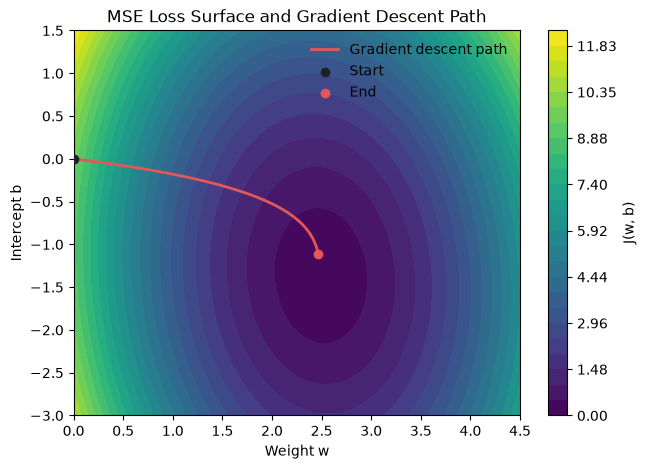

In [2]:
# 复现图 2：损失曲面与梯度下降路径
w_grid, b_grid = np.meshgrid(
    np.linspace(0.0, 4.5, 220),
    np.linspace(-3.0, 1.5, 220),
)
loss_grid = np.mean(
    (y_fig - w_grid[..., None] * x_fig - b_grid[..., None]) ** 2,
    axis=-1,
) / 2

w_path = [0.0]
b_path = [0.0]
learning_rate_fig = 0.05
for _ in range(35):
    w_cur, b_cur = w_path[-1], b_path[-1]
    residual_fig = y_fig - w_cur * x_fig - b_cur
    gradient_w = -np.mean(x_fig * residual_fig)
    gradient_b = -np.mean(residual_fig)
    w_path.append(w_cur - learning_rate_fig * gradient_w)
    b_path.append(b_cur - learning_rate_fig * gradient_b)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
filled = ax.contourf(
    w_grid, b_grid, loss_grid,
    levels=np.linspace(0, loss_grid.max(), 26),
    cmap="viridis",
)
fig.colorbar(filled, ax=ax, label="J(w, b)")
ax.plot(w_path, b_path, color="#E45756", linewidth=2.0,
        label="Gradient descent path")
ax.scatter(w_path[0], b_path[0], color="#202124", zorder=3,
           label="Start")
ax.scatter(w_path[-1], b_path[-1], color="#E45756", zorder=3,
           label="End")
ax.set(xlabel="Weight w", ylabel="Intercept b",
       title="MSE Loss Surface and Gradient Descent Path")
ax.legend(frameon=False)
plt.show()

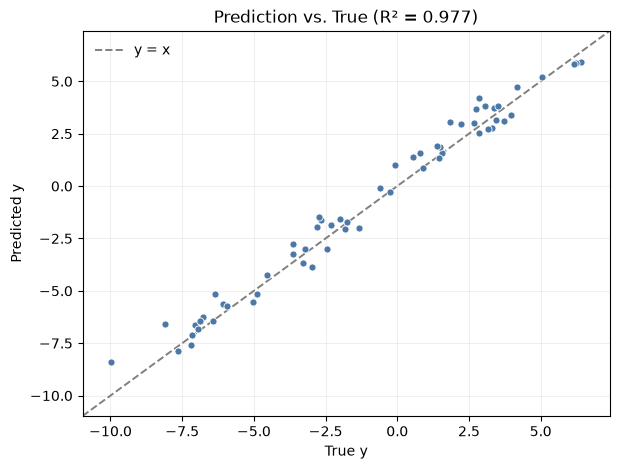

In [3]:
# 复现图 3：真实值—预测值与 R²
w_gd, b_gd = w_path[-1], b_path[-1]
y_pred_fig = w_gd * x_fig + b_gd
ss_res_fig = np.sum((y_fig - y_pred_fig) ** 2)
ss_tot_fig = np.sum((y_fig - y_fig.mean()) ** 2)
r2_fig = 1 - ss_res_fig / ss_tot_fig

fig, ax = plt.subplots(figsize=(6.8, 5.0))
ax.scatter(y_fig, y_pred_fig, s=26, color="#4C78A8",
           edgecolor="white", linewidth=0.6, zorder=3)
lim_low = min(y_fig.min(), y_pred_fig.min()) - 1.0
lim_high = max(y_fig.max(), y_pred_fig.max()) + 1.0
ax.plot([lim_low, lim_high], [lim_low, lim_high],
        "--", color="gray", linewidth=1.4, label="y = x")
ax.set(xlabel="True y", ylabel="Predicted y",
       title=f"Prediction vs. True (R² = {r2_fig:.3f})",
       xlim=(lim_low, lim_high), ylim=(lim_low, lim_high))
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

<a id="scratch-data"></a>
### 2.2 数据准备：一维带噪模拟数据

本节使用 NumPy 生成一维带噪数据：

$$
y=2.5x-1.2+\varepsilon,
\qquad
\varepsilon\sim\mathcal N(0,0.8^2)
$$

\(x\) 从 \([-3,3]\) 均匀采样，共 120 个样本，固定随机种子为 42，
再按 80%/20% 划分训练集和测试集。一维数据可以直接画出拟合直线和残差，
适合展示回归的每个环节；真实多特征数据则交给第 3 节的 sklearn 案例。

In [4]:
import numpy as np

rng = np.random.default_rng(42)
manual_x = rng.uniform(-3, 3, 120)
manual_y = 2.5 * manual_x - 1.2 + rng.normal(0, 0.8, 120)

indices = rng.permutation(len(manual_x))
split = int(0.8 * len(manual_x))
train_idx, test_idx = indices[:split], indices[split:]

manual_X_train = manual_x[train_idx].reshape(-1, 1)
manual_X_test = manual_x[test_idx].reshape(-1, 1)
manual_y_train = manual_y[train_idx]
manual_y_test = manual_y[test_idx]

print(f"训练集样本数: {len(manual_y_train)}")
print(f"测试集样本数: {len(manual_y_test)}")
print("生成公式: y = 2.5x - 1.2 + ε, ε ~ N(0, 0.8²)")

训练集样本数: 96
测试集样本数: 24
生成公式: y = 2.5x - 1.2 + ε, ε ~ N(0, 0.8²)


<a id="scratch-model"></a>
### 2.3 模型实现：`LinearRegressionGD` 与正规方程

`LinearRegressionGD.fit` 用批量梯度下降学习参数，并记录每一轮的 MSE 损失；
`predict` 用学到的参数输出预测值。同时用 `np.linalg.pinv` 实现正规方程解，
作为闭式解的对照。

In [5]:
class LinearRegressionGD:
    '''使用批量梯度下降实现的教学版线性回归。'''

    def __init__(self, learning_rate=0.05, epochs=300):
        self.learning_rate = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        X = np.asarray(X, dtype=float).reshape(-1, 1)
        y = np.asarray(y, dtype=float)
        X_b = np.c_[np.ones(len(X)), X]

        self.theta_ = np.zeros(X_b.shape[1])
        self.loss_history_ = []

        for _ in range(self.epochs):
            prediction = X_b @ self.theta_
            residual = y - prediction
            self.loss_history_.append(
                np.mean(residual ** 2)
            )
            gradient = -(X_b.T @ residual) / len(X)
            self.theta_ -= (
                self.learning_rate * gradient
            )

        self.intercept_ = self.theta_[0]
        self.coef_ = self.theta_[1:]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float).reshape(-1, 1)
        X_b = np.c_[np.ones(len(X)), X]
        return X_b @ self.theta_


manual_X_b_train = np.c_[
    np.ones(len(manual_X_train)),
    manual_X_train,
]
manual_theta_normal = (
    np.linalg.pinv(manual_X_b_train)
    @ manual_y_train
)
print(
    "正规方程解: w =",
    round(float(manual_theta_normal[1]), 3),
    ", b =",
    round(float(manual_theta_normal[0]), 3),
)

正规方程解: w = 2.532 , b = -1.209


<a id="scratch-evaluation"></a>
### 2.4 训练评估：Loss、拟合线与回归指标

`fit` 阶段最小化的是连续、可导的 MSE，因此梯度下降可以稳定下降。
训练完成后，在测试集上计算回归指标：MSE 与训练损失同源；
RMSE 与 \(y\) 同量纲；MAE 对离群点更稳健；\(R^2\) 表示模型解释的方差比例。

下面先看 Loss 是否单调下降，再把拟合线画在散点上，最后给出测试集指标表。

In [6]:
from IPython.display import HTML, display


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))

In [7]:
manual_model = LinearRegressionGD().fit(
    manual_X_train,
    manual_y_train,
)
manual_pred = manual_model.predict(manual_X_test)

manual_mse = np.mean(
    (manual_y_test - manual_pred) ** 2
)
manual_rmse = np.sqrt(manual_mse)
manual_mae = np.mean(
    np.abs(manual_y_test - manual_pred)
)
manual_ss_res = np.sum(
    (manual_y_test - manual_pred) ** 2
)
manual_ss_tot = np.sum(
    (manual_y_test - manual_y_test.mean()) ** 2
)
manual_r2 = 1 - manual_ss_res / manual_ss_tot

print(
    "梯度下降参数: w =",
    round(float(manual_model.coef_[0]), 3),
    ", b =",
    round(float(manual_model.intercept_), 3),
)
print(
    "正规方程参数: w =",
    round(float(manual_theta_normal[1]), 3),
    ", b =",
    round(float(manual_theta_normal[0]), 3),
)
print(
    "测试集: MSE =",
    round(manual_mse, 3),
    ", RMSE =",
    round(manual_rmse, 3),
    ", MAE =",
    round(manual_mae, 3),
    ", R² =",
    round(manual_r2, 3),
)

display_result_table(
    "手写模型：测试集回归指标（test metrics）",
    ["指标", "数值"],
    [
        ["MSE", f"{manual_mse:.3f}"],
        ["RMSE", f"{manual_rmse:.3f}"],
        ["MAE", f"{manual_mae:.3f}"],
        ["R²", f"{manual_r2:.3f}"],
    ],
)

梯度下降参数: w = 2.532 , b = -1.209
正规方程参数: w = 2.532 , b = -1.209
测试集: MSE = 0.777 , RMSE = 0.881 , MAE = 0.696 , R² = 0.945


指标,数值
MSE,0.777
RMSE,0.881
MAE,0.696
R²,0.945


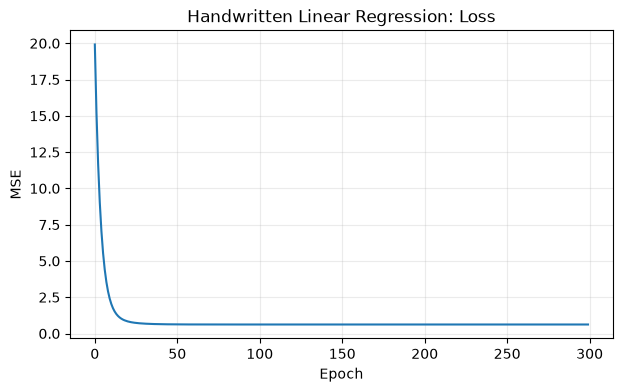

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(manual_model.loss_history_)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Handwritten Linear Regression: Loss")
plt.grid(alpha=0.25)
plt.show()

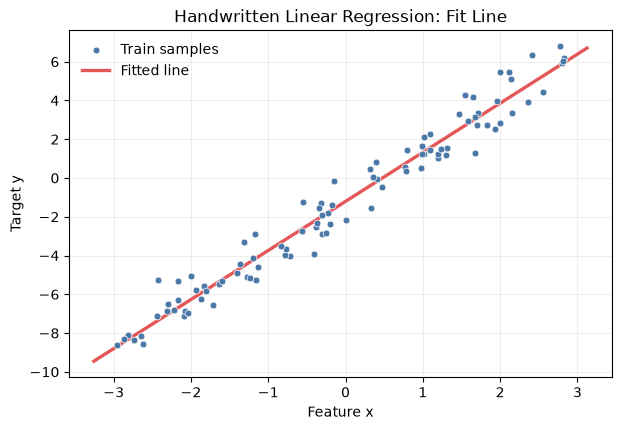

In [9]:
xs = np.linspace(
    manual_X_train.min() - 0.3,
    manual_X_train.max() + 0.3,
    100,
)
line = manual_model.predict(xs.reshape(-1, 1))

plt.figure(figsize=(7, 4.5))
plt.scatter(
    manual_X_train,
    manual_y_train,
    s=24,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.5,
    label="Train samples",
    zorder=3,
)
plt.plot(xs, line, color="#E45756", linewidth=2.4,
         label="Fitted line")
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.title("Handwritten Linear Regression: Fit Line")
plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.show()

<a id="sklearn"></a>
## 3. sklearn 调用与案例

<a id="sklearn-basic"></a>
### 3.1 回归调用：拟合面与残差评估

完整流程：生成或加载数据 → 划分训练集与测试集 → Pipeline 标准化
→ `fit` → `predict` → 指标 → 可视化。

In [10]:
from sklearn.datasets import (
    load_diabetes,
    make_regression,
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

basic_X, basic_y = make_regression(
    n_samples=200,
    n_features=2,
    noise=12,
    random_state=42,
)
(
    basic_X_train,
    basic_X_test,
    basic_y_train,
    basic_y_test,
) = train_test_split(
    basic_X,
    basic_y,
    test_size=0.2,
    random_state=42,
)

basic_model = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)
basic_model.fit(basic_X_train, basic_y_train)
basic_pred = basic_model.predict(basic_X_test)

basic_metrics = {
    "MSE": mean_squared_error(
        basic_y_test,
        basic_pred,
    ),
    "RMSE": float(np.sqrt(
        mean_squared_error(
            basic_y_test,
            basic_pred,
        )
    )),
    "MAE": mean_absolute_error(
        basic_y_test,
        basic_pred,
    ),
    "R2": r2_score(
        basic_y_test,
        basic_pred,
    ),
}

print("基础示例：二维合成回归")
for name, value in basic_metrics.items():
    print(f"{name}: {value:.4f}")

基础示例：二维合成回归
MSE: 146.3801
RMSE: 12.0988
MAE: 9.6116
R2: 0.9513


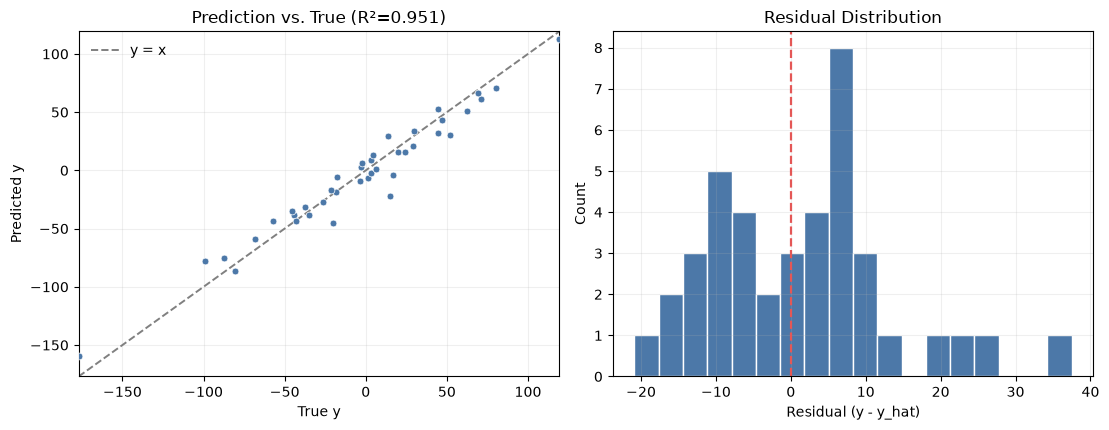

In [11]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.4),
)

axes[0].scatter(
    basic_y_test,
    basic_pred,
    s=24,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
lims = [
    min(basic_y_test.min(), basic_pred.min()),
    max(basic_y_test.max(), basic_pred.max()),
]
axes[0].plot(
    lims,
    lims,
    "--",
    color="gray",
    linewidth=1.4,
    label="y = x",
)
axes[0].set(
    xlabel="True y",
    ylabel="Predicted y",
    title=f"Prediction vs. True (R²={basic_metrics['R2']:.3f})",
    xlim=lims,
    ylim=lims,
)
axes[0].legend(frameon=False)

basic_residuals = basic_y_test - basic_pred
axes[1].hist(
    basic_residuals,
    bins=18,
    color="#4C78A8",
    edgecolor="white",
)
axes[1].axvline(
    0,
    color="#E45756",
    linewidth=1.6,
    linestyle="--",
)
axes[1].set(
    xlabel="Residual (y - y_hat)",
    ylabel="Count",
    title="Residual Distribution",
)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

<a id="real-case"></a>
### 3.2 回归案例：糖尿病进展预测

`load_diabetes` 包含 442 名糖尿病患者的 10 个基线医学指标
（年龄、BMI、血压、血清指标等），目标是一年后疾病进展的量化评分
（越高越严重）。本例用全部 10 个特征预测该评分。

回归模型的“决策边界”是特征空间中的超平面，无法直接画在二维平面。
下面用真实值—预测值散点、残差分布和特征系数条形图来评估模型。

真实场景：糖尿病进展预测
样本数: 442, 特征数: 10
MSE: 2900.1936
RMSE: 53.8534
MAE: 42.7941
R2: 0.4526


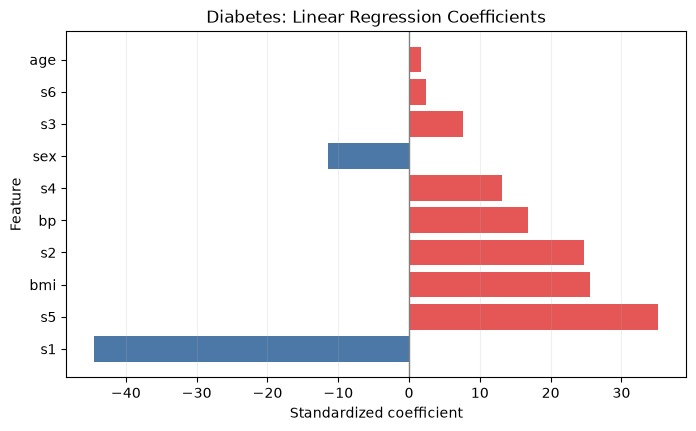

In [12]:
diabetes = load_diabetes()
(
    diabetes_X_train,
    diabetes_X_test,
    diabetes_y_train,
    diabetes_y_test,
) = train_test_split(
    diabetes.data,
    diabetes.target,
    test_size=0.2,
    random_state=42,
)

diabetes_model = make_pipeline(
    StandardScaler(),
    LinearRegression(),
)
diabetes_model.fit(
    diabetes_X_train,
    diabetes_y_train,
)
diabetes_pred = diabetes_model.predict(
    diabetes_X_test
)

diabetes_metrics = {
    "MSE": mean_squared_error(
        diabetes_y_test,
        diabetes_pred,
    ),
    "RMSE": float(np.sqrt(
        mean_squared_error(
            diabetes_y_test,
            diabetes_pred,
        )
    )),
    "MAE": mean_absolute_error(
        diabetes_y_test,
        diabetes_pred,
    ),
    "R2": r2_score(
        diabetes_y_test,
        diabetes_pred,
    ),
}

print("真实场景：糖尿病进展预测")
print(
    f"样本数: {diabetes.data.shape[0]}, "
    f"特征数: {diabetes.data.shape[1]}"
)
for name, value in diabetes_metrics.items():
    print(f"{name}: {value:.4f}")

coefficients = (
    diabetes_model.named_steps["linearregression"].coef_
)
order = np.argsort(
    np.abs(coefficients)
)[::-1]
colors = [
    "#E45756" if c >= 0 else "#4C78A8"
    for c in coefficients[order]
]

plt.figure(figsize=(8, 4.5))
plt.barh(
    [diabetes.feature_names[i] for i in order],
    coefficients[order],
    color=colors,
)
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Diabetes: Linear Regression Coefficients")
plt.grid(axis="x", alpha=0.2)
plt.show()

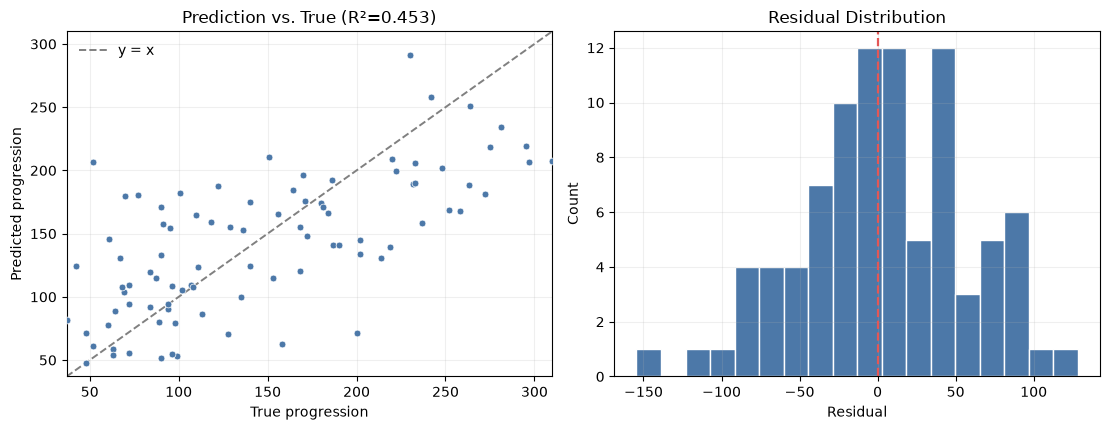

In [13]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.2, 4.4),
)

axes[0].scatter(
    diabetes_y_test,
    diabetes_pred,
    s=24,
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
lims = [
    min(diabetes_y_test.min(), diabetes_pred.min()),
    max(diabetes_y_test.max(), diabetes_pred.max()),
]
axes[0].plot(
    lims,
    lims,
    "--",
    color="gray",
    linewidth=1.4,
    label="y = x",
)
axes[0].set(
    xlabel="True progression",
    ylabel="Predicted progression",
    title=f"Prediction vs. True (R²={diabetes_metrics['R2']:.3f})",
    xlim=lims,
    ylim=lims,
)
axes[0].legend(frameon=False)

diabetes_residuals = diabetes_y_test - diabetes_pred
axes[1].hist(
    diabetes_residuals,
    bins=18,
    color="#4C78A8",
    edgecolor="white",
)
axes[1].axvline(
    0,
    color="#E45756",
    linewidth=1.6,
    linestyle="--",
)
axes[1].set(
    xlabel="Residual",
    ylabel="Count",
    title="Residual Distribution",
)

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

<a id="summary"></a>
## 4. 章节小结

- 线性回归假设目标值是特征的线性组合，最小化残差平方和。
- 正规方程给出闭式解；数据量大或特征相关时改用梯度下降。
- 回归评估使用 MSE、RMSE、MAE 与 R²，并结合真实值—预测值与残差图，而不是只看 R²。
- 真实案例不强行绘制高维边界，重点检查残差是否随机分布、系数是否符合业务直觉。
- 书籍、GitHub 项目和官方文档已列在本章开头。

In [14]:
import json

all_metrics = [
    manual_mse,
    manual_rmse,
    manual_mae,
    manual_r2,
    *basic_metrics.values(),
    *diabetes_metrics.values(),
]
assert np.all(np.isfinite(all_metrics))
assert basic_metrics["R2"] > 0.5
assert diabetes_metrics["R2"] > 0.2
validation = {
    "manual_mse": float(manual_mse),
    "manual_loss_start": float(
        manual_model.loss_history_[0]
    ),
    "manual_loss_end": float(
        manual_model.loss_history_[-1]
    ),
    "manual_r2": float(manual_r2),
    "basic_r2": float(basic_metrics["R2"]),
    "diabetes_r2": float(diabetes_metrics["R2"]),
    "diabetes_rmse": float(diabetes_metrics["RMSE"]),
    "image_count": 8,
}
assert validation["manual_loss_end"] < validation["manual_loss_start"]

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["手写模型 Loss", f'{validation["manual_loss_start"]:.3f} → {validation["manual_loss_end"]:.3f}', "通过"],
        ["手写模型 R²", f'{validation["manual_r2"]:.3f}', "通过"],
        ["基础 sklearn R²", f'{validation["basic_r2"]:.3f}', "通过"],
        ["糖尿病 R²", f'{validation["diabetes_r2"]:.3f}', "通过"],
        ["糖尿病 RMSE", f'{validation["diabetes_rmse"]:.3f}', "通过"],
        ["已执行图表输出", f'{validation["image_count"]}', "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

检查项,观测值,状态
手写模型 Loss,19.915 → 0.622,通过
手写模型 R²,0.945,通过
基础 sklearn R²,0.951,通过
糖尿病 R²,0.453,通过
糖尿病 RMSE,53.853,通过
已执行图表输出,8,通过
